In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns


base = Path("/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots")
ds_ids = ["DS00", "DS01","DS02", "DS03", "DS04", "DS05", "DS06", "DS07", "DS08", "DS09"]

In [53]:
mag_cols = ["mean_mag_umb", "mean_mag_pen", "mean_mag_both", "mean_mag_quiet", "mean_mag_hotspot"]
dop_cols = ["mean_dop_umb", "mean_dop_pen", "mean_dop_both", "mean_dop_quiet"]

mag_dfs = []
for ds in ds_ids:
    csv_path = base / ds / "metrics.csv"
    available = pd.read_csv(csv_path, nrows=0).columns
    cols = ["time_h"] + [c for c in mag_cols + dop_cols if c in available]
    df = pd.read_csv(csv_path, nrows=250, usecols=cols)
    if "mean_mag_hotspot" not in df:
        df["mean_mag_hotspot"] = np.nan
    df["ds"] = ds
    mag_dfs.append(df)

mag_data = pd.concat(mag_dfs, ignore_index=True)
mag_data.head()

,time_h,mean_mag_umb,mean_mag_pen,mean_mag_both,mean_mag_quiet,mean_dop_umb,mean_dop_pen,mean_dop_both,mean_dop_quiet,mean_mag_hotspot,ds
0,0.0,-580.9610,-90.0598,-138.9023,-1.1876,-220.0258,-223.4314,-223.0926,668.1188,641.9320,DS00
1,0.2,-550.8132,-84.4671,-128.9918,-0.6028,-245.0282,-195.6367,-200.3524,501.9637,648.9160,DS00
2,0.4,-485.4500,-87.3461,-127.9137,0.0138,-176.0813,-193.0239,-191.2974,402.8745,646.8465,DS00
3,0.6,-459.9543,-91.9973,-131.1846,1.2353,-191.4076,-158.7180,-162.1995,152.1127,647.8391,DS00
4,0.8,-525.4353,-76.2266,-121.2231,1.3547,-186.7272,-122.2990,-128.7527,-13.4230,646.1091,DS00


In [54]:
def mag_amplitude(time_h, series):
    coeffs = np.polyfit(time_h, series, 2)
    fit = np.polyval(coeffs, time_h)
    residual = series - fit
    return residual.max() - residual.min()

In [55]:
regions = ["umb", "pen", "both", "quiet"]

amp_rows = []
for ds, df in zip(ds_ids, mag_dfs):
    for region in regions:
        dop = df[f"mean_dop_{region}"]
        mag = np.abs(df[f"mean_mag_{region}"])
        amp_rows.append({
            "ds": ds,
            "region": region,
            "dop_amplitude": dop.max() - dop.min(),
            "mag_max": mag_amplitude(df["time_h"], mag),
        })

amp_data = pd.DataFrame(amp_rows)
amp_data

,ds,region,dop_amplitude,mag_max
0,DS00,umb,958.6354,418.242935
1,DS00,pen,649.7698,99.008863
2,DS00,both,681.2533,88.017959
3,DS00,quiet,6215.2268,2.811752
4,DS01,umb,1298.6187,376.432929
5,DS01,pen,806.8194,101.453461
6,DS01,both,862.0843,148.559251
7,DS01,quiet,6002.1157,7.845132
8,DS02,umb,881.5845,307.523236
9,DS02,pen,482.5978,60.252377


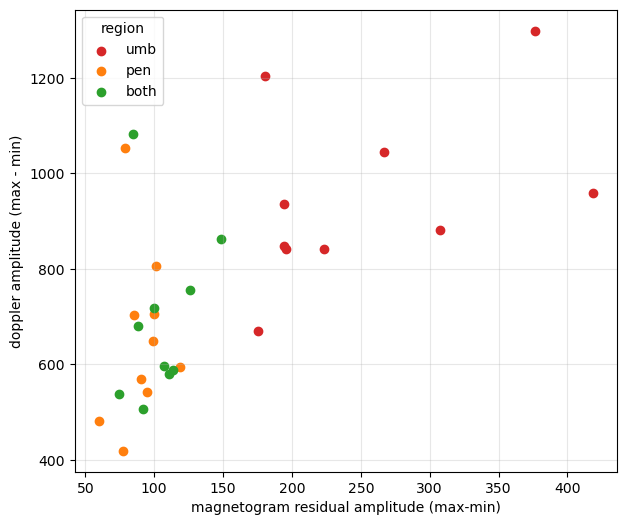

In [ ]:
region_colors = {"umb": "tab:red", "pen": "tab:orange", "both": "tab:green"}

fig, ax = plt.subplots(figsize=(7, 6))
for region, color in region_colors.items():
    subset = amp_data[amp_data["region"] == region]
    ax.scatter(subset["mag_max"], subset["dop_amplitude"], label=region, color=color)

ax.set_xlabel("magnetogram residual amplitude (max-min)")
ax.set_ylabel("doppler amplitude (max - min)")
ax.legend(title="region")
ax.grid(True, alpha=0.3)
plt.show()

In [57]:
# umb/pen amplitudes (mag and dop) vs hotspot mag amplitude, per dataset
corr_rows = []
for ds, df in zip(ds_ids, mag_dfs):
    dop_umb = df["mean_dop_umb"]
    dop_pen = df["mean_dop_pen"]
    mag_umb = np.abs(df["mean_mag_umb"])
    mag_pen = np.abs(df["mean_mag_pen"])
    mag_hotspot = np.abs(df["mean_mag_hotspot"])
    mag_amp_hotspot = mag_amplitude(df["time_h"], mag_hotspot) if mag_hotspot.notna().all() else np.nan
    corr_rows.append({
        "ds": ds,
        "dop_amplitude_umb": dop_umb.max() - dop_umb.min(),
        "dop_amplitude_pen": dop_pen.max() - dop_pen.min(),
        "mag_amplitude_umb": mag_amplitude(df["time_h"], mag_umb),
        "mag_amplitude_pen": mag_amplitude(df["time_h"], mag_pen),
        "mag_amplitude_hotspot": mag_amp_hotspot,
    })

corr_data = pd.DataFrame(corr_rows).set_index("ds")
corr_data

,dop_amplitude_umb,dop_amplitude_pen,mag_amplitude_umb,mag_amplitude_pen,mag_amplitude_hotspot
ds,,,,,
DS00,958.6354,649.7698,418.242935,99.008863,113.891794
DS01,1298.6187,806.8194,376.432929,101.453461,169.528561
DS02,881.5845,482.5978,307.523236,60.252377,NaN
DS03,669.9201,594.2374,175.249472,118.794945,62.145514
DS04,1045.2169,705.7936,266.635354,100.191565,114.599345
DS05,847.7517,703.1938,194.206819,85.499100,81.276495
DS06,1203.4523,1053.2843,180.338696,78.923021,93.162134
DS07,842.2726,569.0533,223.255624,90.482708,89.471707
DS08,842.4117,542.4047,195.816138,95.121537,83.700659


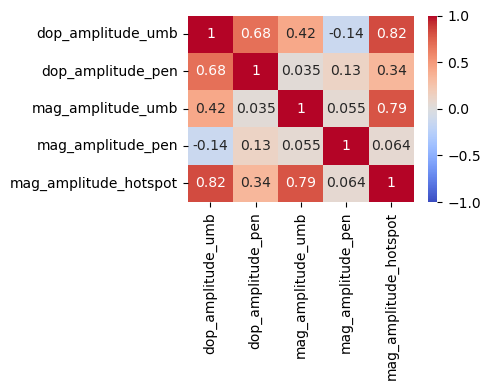

In [58]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
plt.tight_layout()
plt.show()

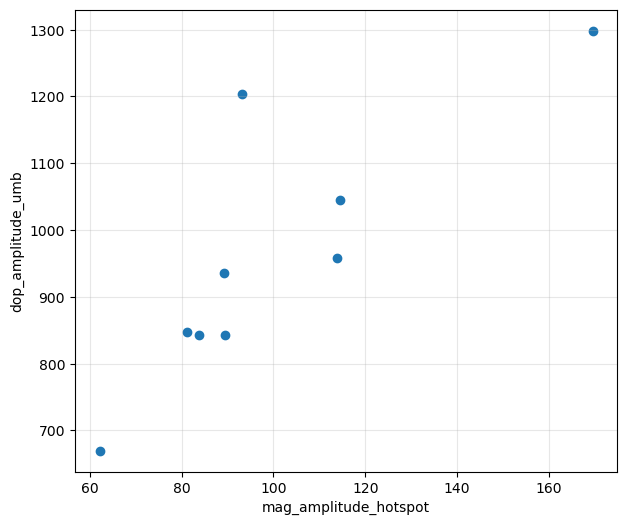

In [65]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(corr_data['mag_amplitude_hotspot'],corr_data['dop_amplitude_umb'])

ax.set_xlabel("mag_amplitude_hotspot")
ax.set_ylabel("dop_amplitude_umb")
ax.grid(True, alpha=0.3)
plt.show();

# Oscilations

In [ ]:


dfs = []
for ds in ds_ids:
    csv_path = base / ds / "plots" / "fft_peaks.csv"
    df = pd.read_csv(csv_path)
    df["ds"] = ds
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data = data[data["region"] != "Both"]
data.head(10)

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0139,1201.3,1.0000,DS00
1,Umbra,2,0.0046,3604.0,0.2185,DS00
2,Umbra,3,0.0247,675.8,0.1611,DS00
3,Umbra,4,0.0339,491.5,0.0467,DS00
4,Umbra,5,0.0509,327.6,0.0407,DS00
5,Penumbra,1,0.0139,1201.3,0.8152,DS00
6,Penumbra,2,0.0046,3604.0,0.3268,DS00
7,Penumbra,3,0.0247,675.8,0.1456,DS00
8,Penumbra,4,0.0370,450.5,0.0591,DS00
9,Penumbra,5,0.0725,230.0,0.0441,DS00


mean period:  1357.42 min


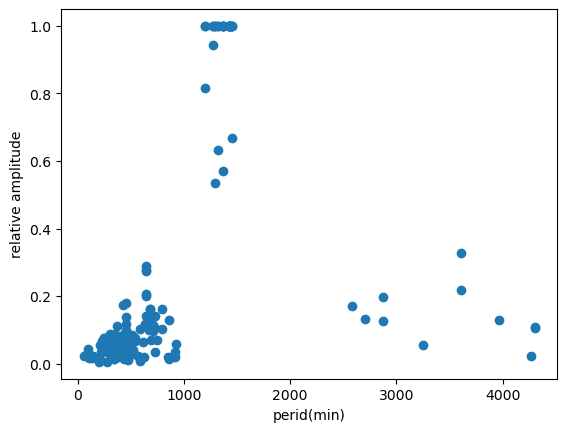

In [21]:
plt.scatter(data['period_min'],data['rel_amplitude']);
plt.xlabel('perid(min)')
plt.ylabel('relative amplitude')

mean_period = data[data['rel_amplitude']>0.5]['period_min'].mean()
print('mean period: ',round(mean_period,2),'min')

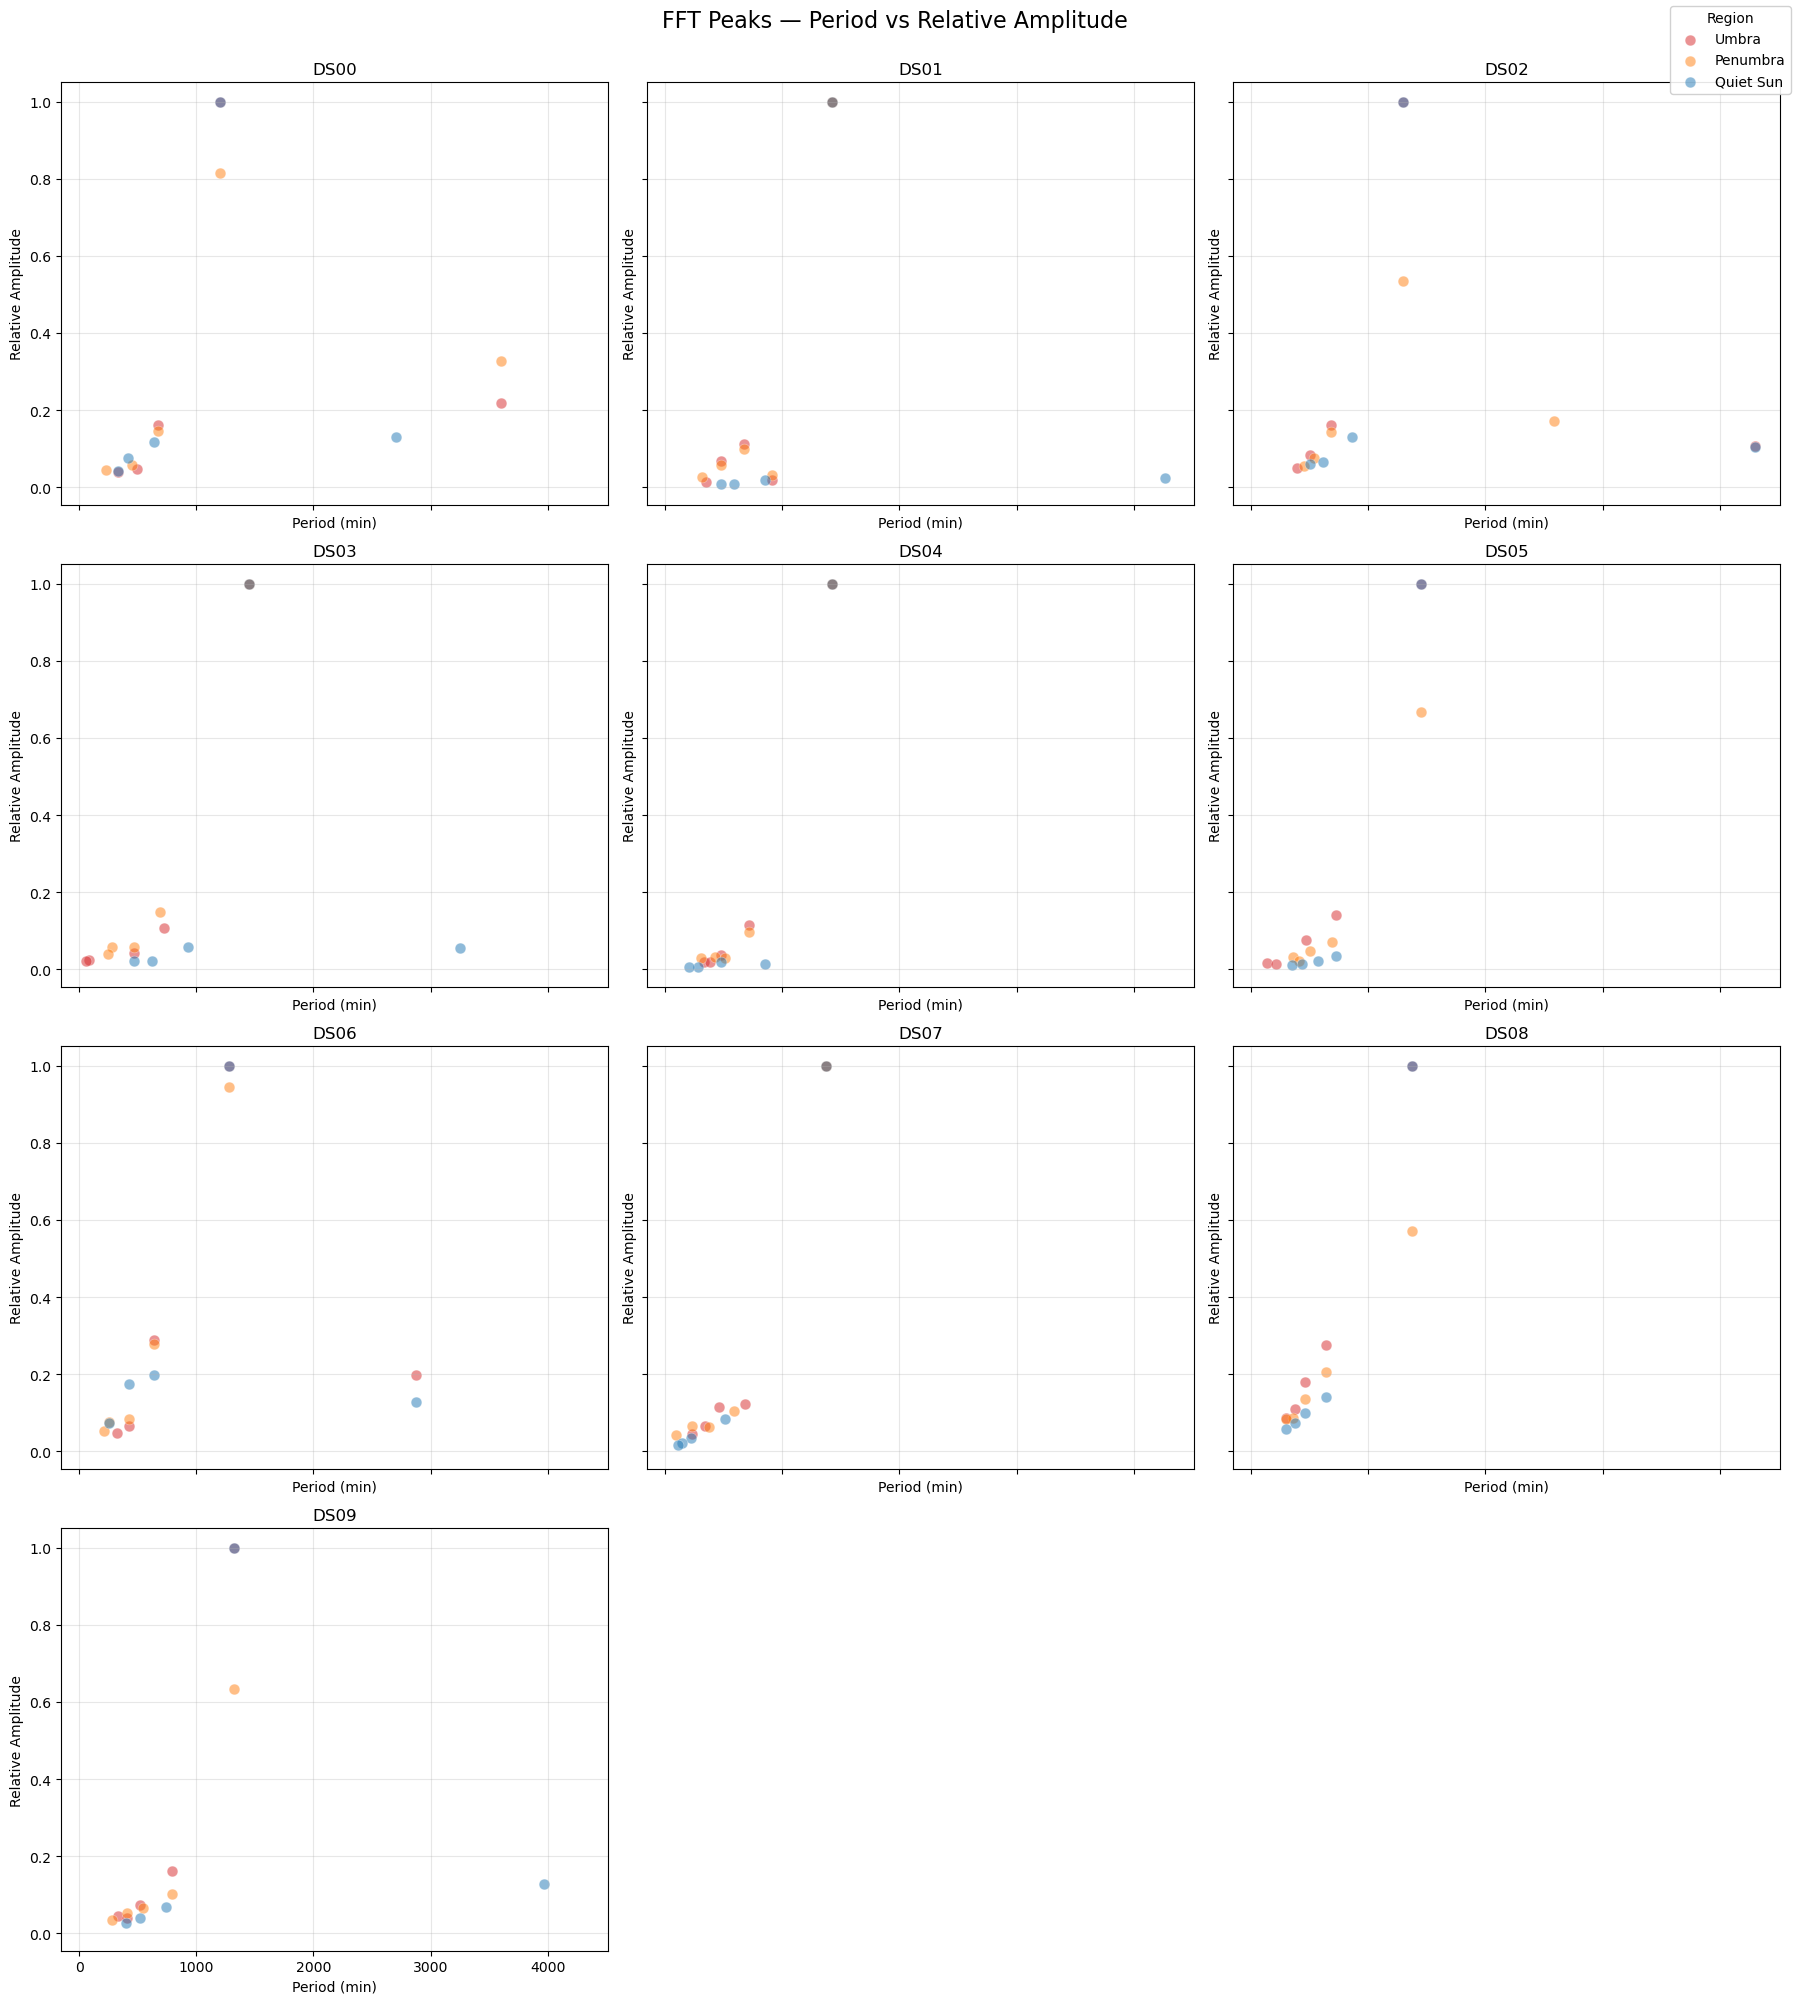

In [10]:
region_colors = {
    "Umbra": "tab:red",
    "Penumbra": "tab:orange",
    "Quiet Sun": "tab:blue",
}

nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, ds in enumerate(ds_ids):
    ax = axes_flat[i]
    subset = data[data["ds"] == ds]
    for region, color in region_colors.items():
        mask = subset["region"] == region
        if mask.any():
            ax.scatter(
                subset.loc[mask, "period_min"],
                subset.loc[mask, "rel_amplitude"],
                label=region,
                color=color,
                alpha=0.5,
                edgecolors="white",
                linewidths=0.4,
                s=60,
            )
    ax.set_title(ds)
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(ds_ids), nrows * ncols):
    axes_flat[j].set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", title="Region", framealpha=0.9)
fig.suptitle("FFT Peaks — Period vs Relative Amplitude", fontsize=16,y=1)
plt.tight_layout()
plt.show()

## DS01

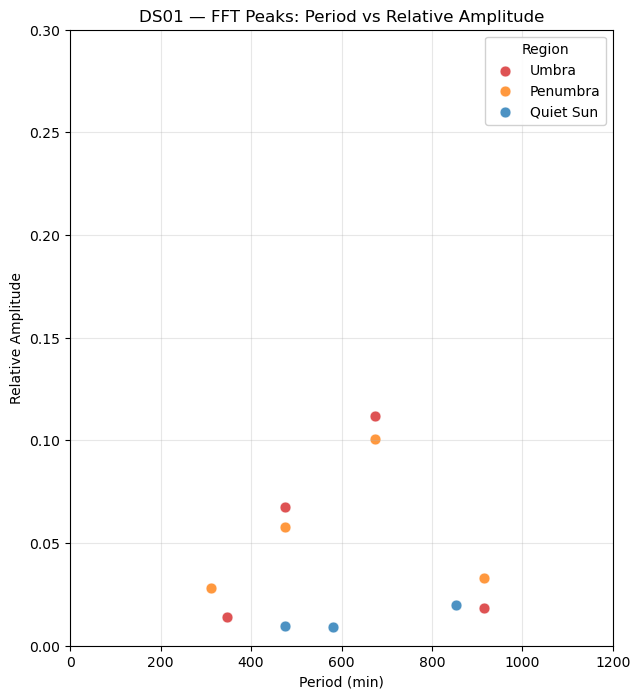

In [16]:
ds = "DS01"

fig, ax = plt.subplots(figsize=(7, 8))
subset = data[data["ds"] == ds]
for region, color in region_colors.items():
    mask = subset["region"] == region
    if mask.any():
        ax.scatter(
            subset.loc[mask, "period_min"],
            subset.loc[mask, "rel_amplitude"],
            label=region,
            color=color,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            s=60,
        )
    ax.set_title(ds+' — FFT Peaks: Period vs Relative Amplitude')
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    if ax is axes[0]:
        ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)
plt.xlim(0,1200)
plt.ylim(0,0.3)
plt.legend(title="Region", framealpha=0.9)

In [17]:
subset

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0117,1422.7,1.0000,DS01
1,Umbra,2,0.0247,673.9,0.1121,DS01
2,Umbra,3,0.0351,474.2,0.0674,DS01
3,Umbra,4,0.0182,914.6,0.0184,DS01
4,Umbra,5,0.0482,346.1,0.0141,DS01
5,Penumbra,1,0.0117,1422.7,1.0000,DS01
6,Penumbra,2,0.0247,673.9,0.1006,DS01
7,Penumbra,3,0.0351,474.2,0.0578,DS01
8,Penumbra,4,0.0182,914.6,0.0329,DS01
9,Penumbra,5,0.0534,312.3,0.0280,DS01


se nota un pico unico para la umbra y la penumbra en $T(min) = 673.9$ y posiblemente uno en $T(min) = 474.2$ pero el Qsun tambien lo tiene, con respecto a la mas predumeante de la umbra, penumbra es $T(min) = 1422.7$ que coincide con la del analisis grafico y del Qsun

## DS03

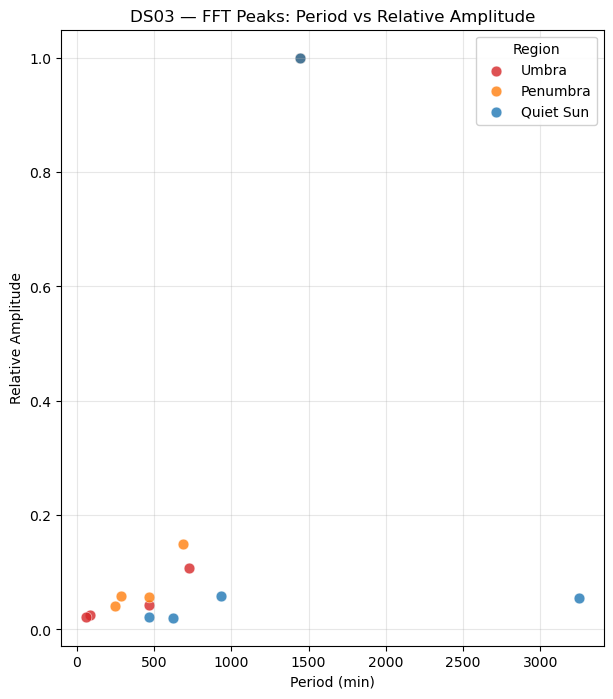

In [15]:
ds = "DS03"

fig, ax = plt.subplots(figsize=(7, 8))

subset = data[data["ds"] == ds]

for region, color in region_colors.items():
    mask = subset["region"] == region
    if mask.any():
        ax.scatter(
            subset.loc[mask, "period_min"],
            subset.loc[mask, "rel_amplitude"],
            label=region,
            color=color,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            s=60,
        )
    ax.set_title(ds+' — FFT Peaks: Period vs Relative Amplitude')
    ax.set_xlabel("Period (min)")
    ax.set_ylabel("Relative Amplitude")
    if ax is axes[0]:
        ax.set_ylabel("Relative Amplitude")
    ax.grid(True, alpha=0.3)

plt.legend(title="Region", framealpha=0.9)

In [18]:
subset

,region,rank,freq_mhz,period_min,rel_amplitude,ds
0,Umbra,1,0.0117,1422.7,1.0000,DS01
1,Umbra,2,0.0247,673.9,0.1121,DS01
2,Umbra,3,0.0351,474.2,0.0674,DS01
3,Umbra,4,0.0182,914.6,0.0184,DS01
4,Umbra,5,0.0482,346.1,0.0141,DS01
5,Penumbra,1,0.0117,1422.7,1.0000,DS01
6,Penumbra,2,0.0247,673.9,0.1006,DS01
7,Penumbra,3,0.0351,474.2,0.0578,DS01
8,Penumbra,4,0.0182,914.6,0.0329,DS01
9,Penumbra,5,0.0534,312.3,0.0280,DS01


# Raw data doplergram comparison

In [5]:
#%load_ext autoreload   
#%autoreload 2

import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.sunspot_analysis import (
    verify_cadence,
    load_and_mask,
    plot_calibration_frame,
    plot_histogram,
    plot_magnetogram_masks,
    plot_area,
    compute_metrics,
    save_metrics_csv,
    plot_ffts_separate,
    plot_ffts_combined,
    save_animation,
)

def plot_time_series(
    data: dict,
    metrics: dict,
    DS0N_NAME:str
) -> None:

    time_h = data['time_h']


    ylabel_dop =  'Mean velocity  (m/s)'

    series = [
        ('Umbra',      metrics['mean_dop_umb'],   'red'),
        ('Penumbra',   metrics['mean_dop_pen'],   'blue'),
        ('Both',       metrics['mean_dop_both'],  'purple'),
        ('Quiet Sun',  metrics['mean_dop_quiet'], 'black'),
    ]

    fig,  ax2 = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    for name, dop, color in series:
        ax2.plot(time_h, dop, color=color, lw=0.8, label=name)

 
    ax2.set_ylabel(ylabel_dop); ax2.set_xlabel('Time  (h)')
    ax2.set_title('Mean dopplergram uncorrected'+' '+DS0N_NAME,)
    ax2.grid(alpha=0.3); ax2.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Raw data dir : ../data/raw/sebastian_sun_spots/DS00


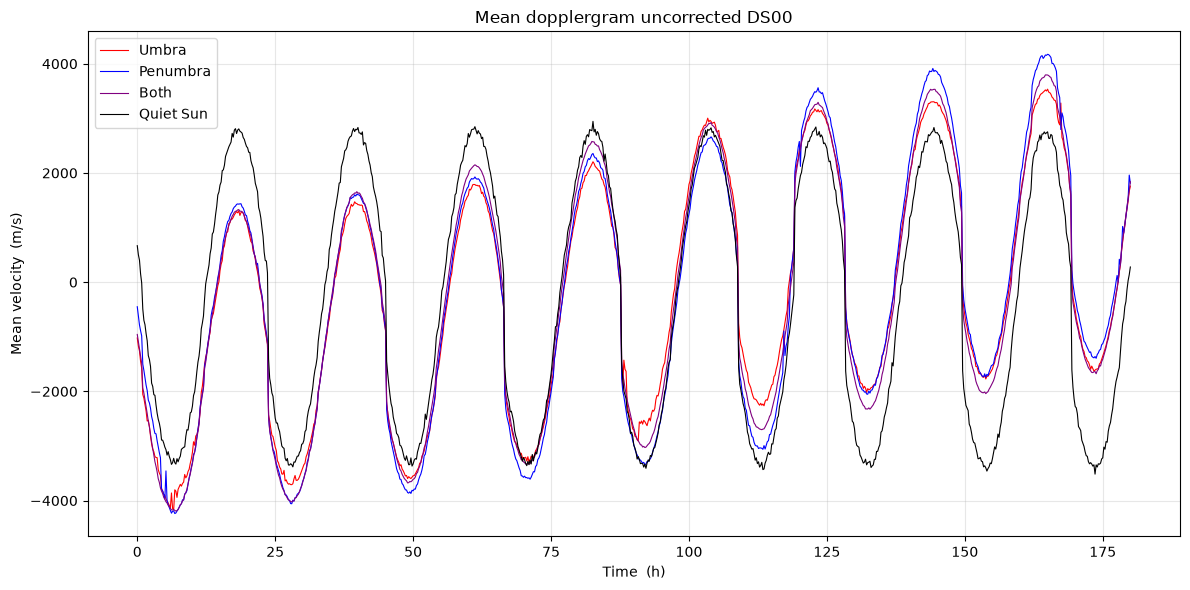

Raw data dir : ../data/raw/sebastian_sun_spots/DS01


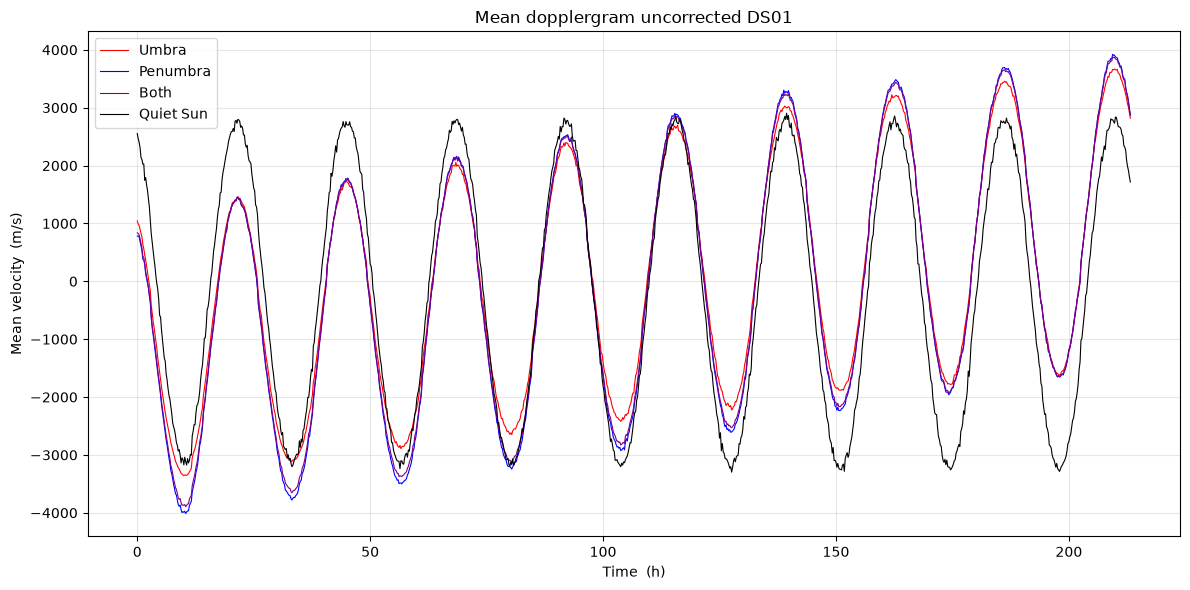

Raw data dir : ../data/raw/sebastian_sun_spots/DS03


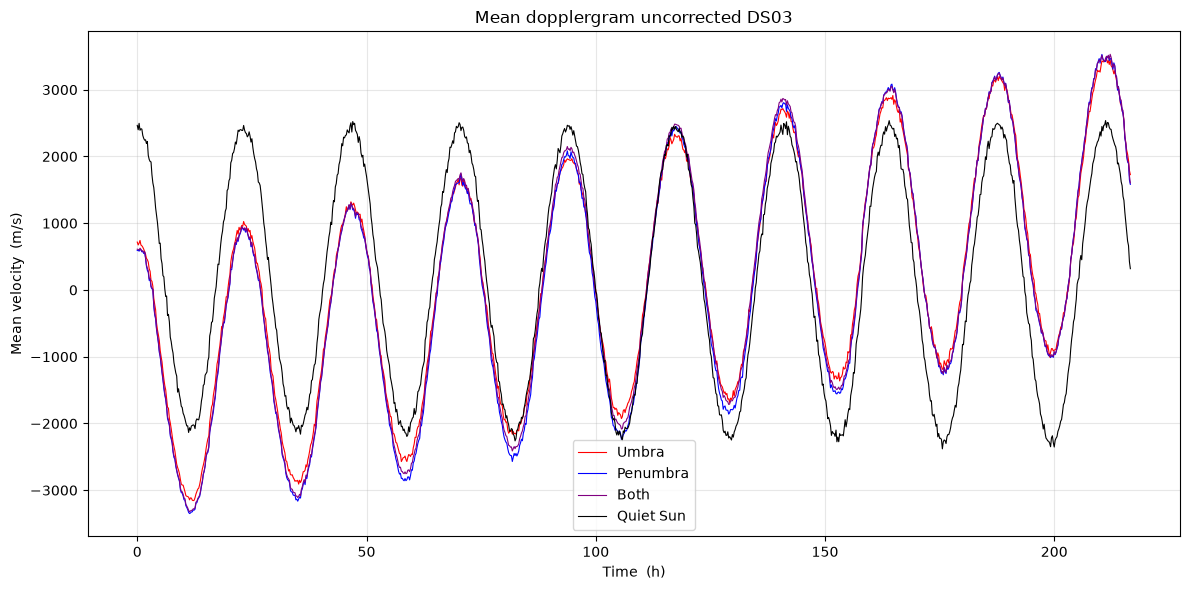

Raw data dir : ../data/raw/sebastian_sun_spots/DS04


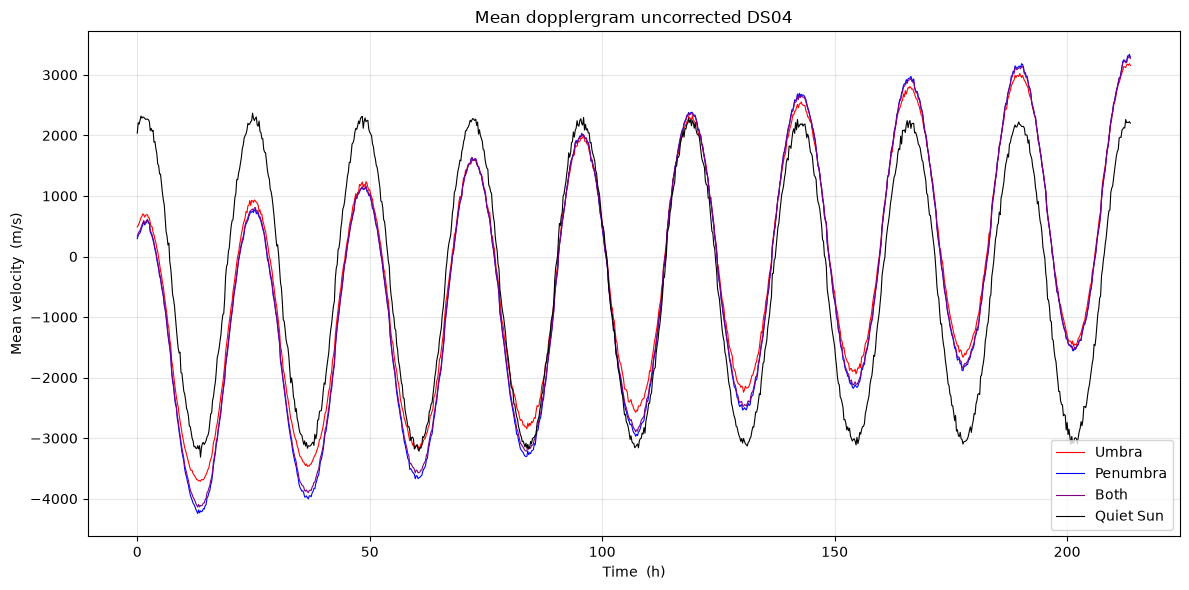

Raw data dir : ../data/raw/sebastian_sun_spots/DS05


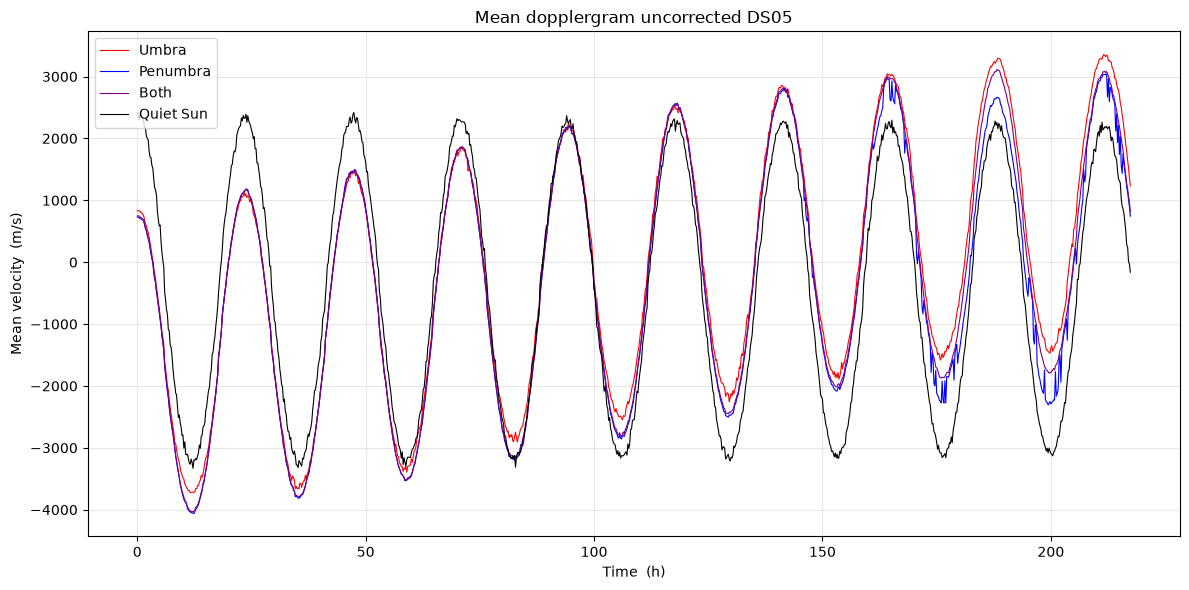

In [7]:
DS0N_list = ['DS00','DS01','DS03','DS04','DS05']
for DS0N_NAME in DS0N_list:
    raw_dir_01      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS0N_NAME
    processed_dir_01 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS0N_NAME
    plots_dir_01    = processed_dir_01 / 'plots'

    print('Raw data dir :', raw_dir_01)
    mag_filter_01 = lambda x : x>500

    data = load_and_mask(
        ds_dir          = raw_dir_01,
        umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
        penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra,
        mag_filter=mag_filter_01,
        cadence_s       = 720,
        raw_dopler = True
    )

    metrics = compute_metrics(data)

    plot_time_series(data, metrics, DS0N_NAME)

In [ ]:
# TODO compose the previos code to make a comparaison for every ds0n of uncorrected doplergram data 
# also make the commit descibing this plot

probably the effect is given by the position of the sun spots in each limb note that there is a clear trend were at the midle the diference bteween quiet and sunspot is minimal 